# Regresión Lineal — Análisis y Caso Real: California Housing Dataset

> **Curso:** Sistemas Basados en Conocimiento
> **Alumno:** Victor Manuel Vargas Miranda
> **Dataset:** [California Housing (sklearn)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)  
> **Librería principal:** [scikit-learn](https://scikit-learn.org/stable/install)  

---

## 1. ¿Qué problema resuelve la Regresión Lineal?

La **Regresión Lineal** es uno de los algoritmos supervisados más fundamentales del aprendizaje automático. Su objetivo es modelar la relación entre una o más variables independientes (características o *features*) y una variable dependiente continua (objetivo o *target*).

Matemáticamente, el modelo busca encontrar los coeficientes $\beta_0, \beta_1, \ldots, \beta_p$ que minimicen el error cuadrático entre las predicciones y los valores reales:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

El criterio de ajuste estándar es la **minimización de la Suma de Cuadrados de Residuos (RSS)**:

$$\text{RSS} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**Tipos de problemas que resuelve:**
- Predicción de valores continuos (precios, temperaturas, ventas, etc.).
- Cuantificación del efecto de cada variable sobre el objetivo.
- Inferencia estadística sobre las relaciones entre variables.

## 2. Supuestos Fundamentales del Modelo

La Regresión Lineal descansa en seis supuestos clave. Violarlos no siempre invalida el modelo, pero sí puede sesgar las estimaciones y los intervalos de confianza.

| # | Supuesto | Descripción |
|---|----------|-------------|
| 1 | **Linealidad** | La relación entre las variables independientes y la dependiente es lineal. |
| 2 | **Independencia** | Las observaciones son independientes entre sí. |
| 3 | **Homocedasticidad** | La varianza de los residuos es constante para todos los valores de X. |
| 4 | **Normalidad de residuos** | Los errores siguen una distribución normal (crítico para inferencia estadística). |
| 5 | **Sin multicolinealidad** | Las variables independientes no están altamente correlacionadas entre sí. |
| 6 | **Sin valores atípicos influyentes** | Los outliers no distorsionan excesivamente los coeficientes. |

## 3. Usos y Aplicaciones Potenciales

- **Economía y finanzas:** predicción de precios de activos, estimación de demanda, proyección de ingresos.
- **Bienes raíces:** valoración de propiedades (como el caso práctico que se aborda en este notebook).
- **Ciencias de la salud:** modelado de respuestas a dosis de medicamentos, predicción de indicadores clínicos.
- **Ingeniería:** análisis de resistencia de materiales, predicción de consumo energético.
- **Marketing:** relación entre inversión publicitaria y ventas.
- **Ciencias ambientales:** modelos de temperatura, calidad del aire, precipitaciones.

## 4. ¿En Qué Tipos de Problemas es Apropiada?

La Regresión Lineal es especialmente adecuada cuando:

1. La variable de salida es **continua** (no categórica).
2. Se espera (o puede verificarse) una relación aproximadamente **lineal** entre features y target.
3. El conjunto de datos es **relativamente pequeño** o los recursos computacionales son limitados.
4. Se requiere **explicabilidad** e **interpretabilidad** directa de los resultados.
5. Se necesita **inferencia estadística** formal sobre los coeficientes (p-values, intervalos de confianza).
6. El dominio del problema favorece **relaciones aditivas** entre variables.

## 5. ¿Cuándo es Preferible Frente a Modelos Más Complejos?

Aunque modelos como Random Forest, Gradient Boosting o Redes Neuronales suelen superar a la Regresión Lineal en precisión predictiva, existen escenarios donde la regresión lineal es la mejor elección:

| Situación | Razón |
|-----------|-------|
| Datos limitados (pocos registros) | Modelos complejos sobreajustan fácilmente; la regresión lineal generaliza mejor con escasos datos. |
| Alta dimensionalidad con relaciones lineales | Eficiente y precisa sin necesitar feature engineering elaborado. |
| Necesidad de explicación a stakeholders no técnicos | Los coeficientes tienen interpretación directa. |
| Requisitos regulatorios de transparencia | Sectores como banca, salud o seguros exigen modelos auditables. |
| Prototipado y baseline | Establecer un punto de comparación antes de probar modelos más complejos. |
| Tiempo real o recursos muy limitados | Latencia mínima de inferencia (una simple multiplicación de vectores). |

## 6. Pros y Contras desde la Perspectiva de XAI (Explainable AI)

### ✅ Ventajas (XAI)

1. **Interpretabilidad nativa:** Cada coeficiente $\beta_i$ cuantifica el cambio esperado en $y$ por una unidad de cambio en $x_i$, manteniendo constantes las demás variables (*ceteris paribus*).
2. **Transparencia global:** El modelo entero es inspecionable con una sola ecuación.
3. **Medir importancia de cada variable:** Los coeficientes estandarizados revelan la importancia relativa de cada variable.
4. **Scaja de cristal:** No requiere técnicas adicionales como SHAP o LIME para explicar predicciones individuales.
5. **Facilita auditoría:** Ideal para contextos regulados (GDPR, decisiones financieras, decisiones médicas).
6. **Detección de sesgos sencilla:** Fácil identificar si variables sensibles (edad, género) tienen coeficientes inapropiados.

### ❌ Desventajas (XAI)

1. **Incapacidad para capturar no linealidades:** Relaciones curvilíneas o interacciones complejas no quedan reflejadas en el modelo sin transformaciones manuales.
2. **Sensibilidad a outliers:** Valores extremos pueden distorsionar los coeficientes y cambiar drásticamente la interpretación.
3. **Problemas con multicolinealidad:** Coeficientes inestables y difíciles de interpretar cuando features están correlacionadas.
4. **Asume aditividad:** No modela automáticamente interacciones entre variables.
5. **Explicación local limitada:** Para observaciones individuales atípicas, el modelo global puede no explicar bien el comportamiento local.

## 7. Análisis Explícito de Explicabilidad del Modelo

La **explicabilidad** en la Regresión Lineal opera en dos niveles:

### 7.1 Explicabilidad Global
Los coeficientes $\beta$ permiten entender cómo el modelo toma decisiones de forma general:
- Un coeficiente **positivo** indica que al aumentar esa feature, el valor predicho aumenta.
- Un coeficiente **negativo** indica la relación inversa.
- La **magnitud** (preferiblemente estandarizada) indica cuánto contribuye cada variable.

### 7.2 Explicabilidad Local
Para una predicción individual $\hat{y}^{(i)}$, la contribución de cada feature es simplemente $\beta_j \cdot x_j^{(i)}$.

### 7.3 Verificación de Supuestos como Herramienta de Explicabilidad
Analizar los residuos del modelo permite detectar:
- **Patrones sistemáticos** que el modelo no captura (indicando no linealidad).
- **Heterocedasticidad** que indica que el modelo no se comporta igual en todos los rangos de valores.
- **Outliers** que pueden estar dominando las predicciones.

> En este notebook veremos estos conceptos aplicados al dataset California Housing, donde los coeficientes tendrán interpretación directa en términos de precio de vivienda.

---
## Caso Práctico: California Housing Dataset

### Descripción del Problema

"El **California Housing Dataset** proviene del censo de EE.UU. de 1990 y contiene información agregada por *block group* (la unidad geográfica mínima del Censo, con típicamente 600–3000 habitantes). El objetivo es **predecir el valor mediano de las viviendas** (*MedHouseVal*) en cientos de miles de dólares." (Scikit-learn developers, s. f.-a)

**¿Qué se predice y por qué?** Se intenta cuantificar directamente qué factores (ingreso, edad de las casas, densidad poblacional, etc.) y en qué medida contribuyen al precio de las viviendas. La intención es luego poder estimar el precio y además dadas ciertas características predecir cuanto podría valer.

Potenciales usarios de este análisis podrían ser: compradores de vivienda, bancos que otorgan hipotecas, gobiernos que diseñan políticas habitacionales y urbanistas que planifican el desarrollo de ciudades necesitan entender: **¿qué factores determinan el precio de una vivienda y cuál es su impacto cuantificable?** ¿Es el ingreso de la zona? ¿La ubicación geográfica? ¿La densidad poblacional? ¿La antigüedad de las construcciones? La Regresión Lineal permite responder estas preguntas de forma directa e interpretable, cuantificando exactamente cuánto contribuye cada factor al valor de mercado.

**Variables predictoras (8 features numéricas):**

| Feature | Descripción |
|---------|-------------|
| `MedInc` | Ingreso mediano del block group |
| `HouseAge` | Edad mediana de las casas en el block group |
| `AveRooms` | Promedio de habitaciones por hogar |
| `AveBedrms` | Promedio de dormitorios por hogar |
| `Population` | Población del block group |
| `AveOccup` | Promedio de miembros por hogar |
| `Latitude` | Latitud del block group |
| `Longitude` | Longitud del block group |

**Variable objetivo:** `MedHouseVal` — Valor mediano de vivienda en $100,000 USD.

**Fuente:** [StatLib Repository](https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html) — disponible vía [sklearn.datasets.fetch_california_housing](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)

- **Instancias:** 20,640
- **Valores faltantes:** Ninguno

### Instalación de dependencias

Asegúrate de tener instalada la librería `scikit-learn`. Puedes encontrar instrucciones de instalación en: https://scikit-learn.org/stable/install

In [1]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install scikit-learn pandas numpy matplotlib seaborn

### Importación de librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

### Configuración visual

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)

---
## Paso 1: Carga del Dataset

Cargamos el dataset directamente desde scikit-learn. Referencia oficial:  
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html

In [5]:
# Carga del dataset California Housing
housing = fetch_california_housing()

# Crear DataFrame de Pandas para facilitar el análisis
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print('Dataset cargado exitosamente.')
print(f'Dimensiones: {df.shape[0]} instancias x {df.shape[1]} columnas')
print(f'Features: {housing.feature_names}')
print(f'Target: MedHouseVal (valor mediano de vivienda en $100,000 USD)')

Dataset cargado exitosamente.
Dimensiones: 20640 instancias x 9 columnas
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal (valor mediano de vivienda en $100,000 USD)


In [6]:
# Descripción oficial del dataset
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
# Vista previa de los datos
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


---
## Paso 2: Análisis Exploratorio y Limpieza de Datos

In [8]:
# Estadísticas descriptivas
df.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


In [9]:
# Verificación de valores nulos
missing = df.isnull().sum()
print('Valores nulos por columna:')
print(missing)
print(f'\nTotal de valores nulos: {missing.sum()}')
print('→ No se requiere limpieza de datos faltantes.')

Valores nulos por columna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total de valores nulos: 0
→ No se requiere limpieza de datos faltantes.


In [10]:
# Verificación de tipos de datos
print('Tipos de datos:')
print(df.dtypes)

Tipos de datos:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


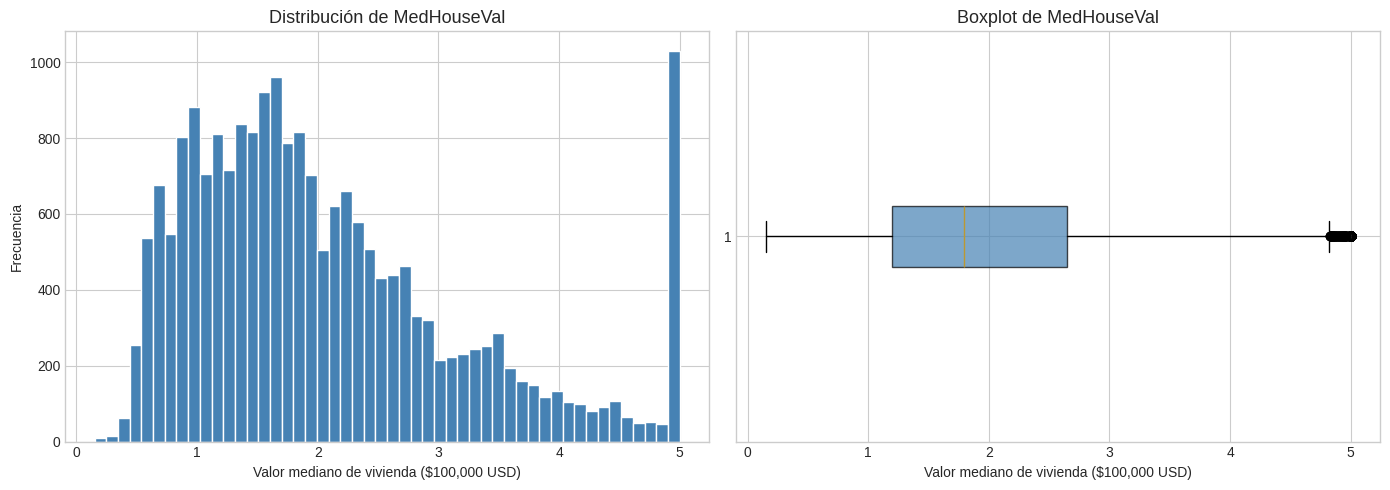

Nota Victor: Se observa un pico en $500,000 (5.0) que puede corresponder a un límite de de datos establecido en el que cualquier valor por encima fue resumido a $500,000 (5.0).


In [11]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de MedHouseVal', fontsize=13)
axes[0].set_xlabel('Valor mediano de vivienda ($100,000 USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['MedHouseVal'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot de MedHouseVal', fontsize=13)
axes[1].set_xlabel('Valor mediano de vivienda ($100,000 USD)')

plt.tight_layout()
plt.show()

print(f'Nota Victor: Se observa un pico en $500,000 (5.0) que puede corresponder a un límite de de datos establecido en el que cualquier valor por encima fue resumido a $500,000 (5.0).')

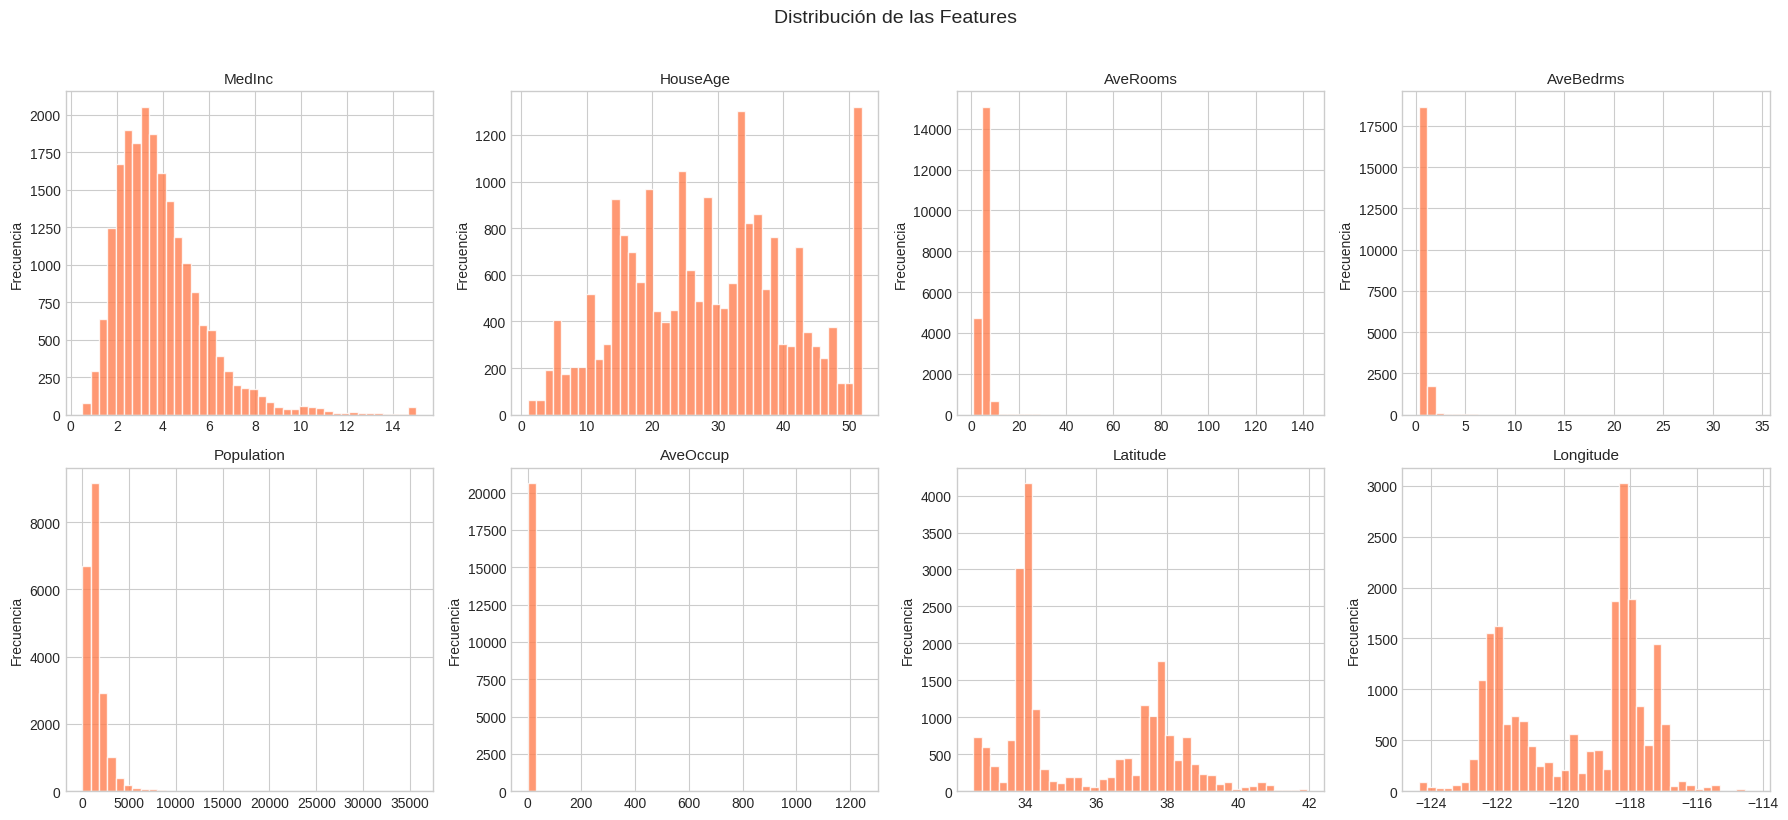

Nota Victor: El ingreso medio es la variable que parece tener una distribucion mas normalizada, seguido por la edad de la vivienda.
Nota Victor: Numero de cuartos, numero de habitaciones ocupacion y poblacion parecen estar concentrados.


In [12]:
# Distribución de todas las features
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(housing.feature_names):
    axes[i].hist(df[col], bins=40, color='coral', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de las Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Nota Victor: El ingreso medio es la variable que parece tener una distribucion mas normalizada, seguido por la edad de la vivienda.')
print(f'Nota Victor: Numero de cuartos, numero de habitaciones ocupacion y poblacion parecen estar concentrados.')

**Notas de distribucion de las features:**

- Según podemos observar, las variables que entre ellas parecen tener mayor relación son el ingreso medio con el valor de la vivienda; seguido del ingreso medio y la cantidad de habitaciones de la vivienda.
- El hecho de que las variables no estén altamente relacionadas entre sí es positivo bajo los supuestos de la Regresión Lineal, particularmente en lo relacionado con la ausencia de multicolinealidad, como se explicó al inicio de este notebook.

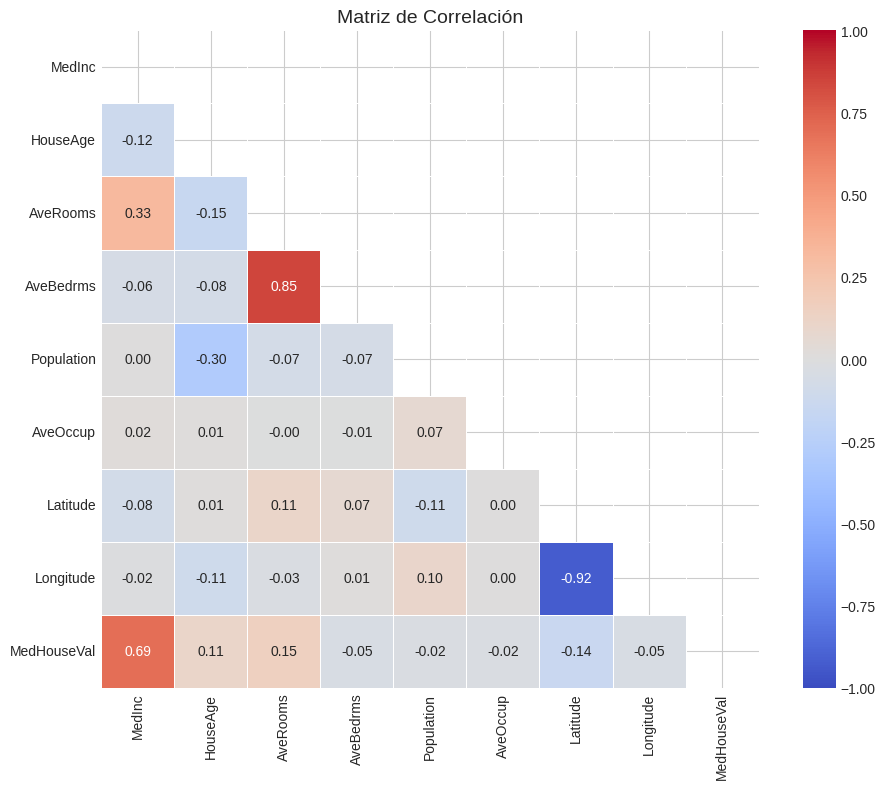

Correlaciones con MedHouseVal (variable objetivo):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160


In [13]:
# Matriz de correlación
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

print('Correlaciones con MedHouseVal (variable objetivo):')
print(corr['MedHouseVal'].sort_values(ascending=False).to_string())

**Interpretación de la correlación:**
- `MedInc` tiene la correlación más alta con el precio (≈0.69), lo que indica que el ingreso mediano es el predictor más importante. El segundo predictor mas importante parece ser la cantidad de habitaciones (≈0.33)
- `Latitude` y `Longitude` tienen correlaciones negativas relevantes, capturando efectos geográficos.
- `AveRooms` y `AveBedrms` están altamente correlacionadas entre sí, lo que puede generar multicolinealidad. Esto deberia ser bastante evidente porque AveBedrms es un subconjunto de AveRooms.

---
## Paso 3: Selección de Variables

Dado que el dataset ya cuenta con variables relevantes y no hay valores faltantes, utilizamos **7 de las 8 features disponibles**, descartando `AveBedrms`. Esta decisión se justifica porque:
1. La correlación con el target es verificable para cada feature.
2. `AveBedrms` presenta alta multicolinealidad con `AveRooms` (correlación ≈ 0.85), lo que genera coeficientes inestables y dificulta la interpretación.
3. Eliminar `AveBedrms` reduce la redundancia de información sin pérdida significativa de poder predictivo.
4. Las 7 features restantes permiten obtener un modelo más interpretable para el análisis de explicabilidad.

In [14]:
# Separación de features y target (se excluye AveBedrms por alta colinealidad con AveRooms)
FEATURES = [f for f in housing.feature_names if f != 'AveBedrms']
X = df[FEATURES]
y = df['MedHouseVal']

print(f'Features (X): {X.shape} — {list(X.columns)}')

print(f'Feature excluida: AveBedrms (alta correlación con AveRooms)')
print(f'Target (y): {y.shape} — MedHouseVal')

Features (X): (20640, 7) — ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Feature excluida: AveBedrms (alta correlación con AveRooms)
Target (y): (20640,) — MedHouseVal


---
## Paso 4: Separación en Conjuntos de Entrenamiento y Prueba

In [15]:
# División 80% entrenamiento — 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} instancias ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Conjunto de prueba:        {X_test.shape[0]} instancias ({X_test.shape[0]/len(X)*100:.1f}%)')

Conjunto de entrenamiento: 16512 instancias (80.0%)
Conjunto de prueba:        4128 instancias (20.0%)


---
## Paso 5: Implementación del Algoritmo con Scikit-Learn

Utilizamos `LinearRegression` de scikit-learn, que implementa la solución por **mínimos cuadrados ordinarios (OLS)** mediante descomposición matricial eficiente (SVD).

Referencia: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [16]:
# Escalado de features (mejora la estabilidad numérica y facilita comparar coeficientes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features escaladas con StandardScaler (media=0, std=1).')

Features escaladas con StandardScaler (media=0, std=1).


---
## Paso 6: Ajuste del Modelo

In [17]:
# Creación e instanciación del modelo
model = LinearRegression()

# Ajuste del modelo a los datos de entrenamiento
model.fit(X_train_scaled, y_train)

print('Modelo entrenado exitosamente.')
print(f'\nIntercepto (β₀): {model.intercept_:.4f}')
print(f'\nCoeficientes (β₁ ... β₇):')
for name, coef in zip(FEATURES, model.coef_):
    print(f'  {name:12s}: {coef:+.4f}')

Modelo entrenado exitosamente.

Intercepto (β₀): 2.0719

Coeficientes (β₁ ... β₇):
  MedInc      : +0.7083
  HouseAge    : +0.1234
  AveRooms    : +0.0456
  Population  : -0.0033
  AveOccup    : -0.0375
  Latitude    : -0.9783
  Longitude   : -0.9317


---
## Paso 7: Evaluación del Modelo

In [18]:
# Predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test_scaled)

# Cálculo de métricas
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
mae  = np.mean(np.abs(y_test - y_pred))

print('=' * 50)
print('       MÉTRICAS DE EVALUACIÓN (Test Set)')
print('=' * 50)
print(f'  MSE  (Error Cuadrático Medio):     {mse:.4f}')
print(f'  RMSE (Raíz del MSE):               {rmse:.4f}  → ±${rmse*100_000:,.0f} USD aprox.')
print(f'  MAE  (Error Absoluto Medio):       {mae:.4f}  → ±${mae*100_000:,.0f} USD aprox.')
print(f'  R²   (Coeficiente de Determinación): {r2:.4f}  → El modelo explica el {r2*100:.1f}% de la varianza.')
print('=' * 50)

       MÉTRICAS DE EVALUACIÓN (Test Set)
  MSE  (Error Cuadrático Medio):     0.5473
  RMSE (Raíz del MSE):               0.7398  → ±$73,982 USD aprox.
  MAE  (Error Absoluto Medio):       0.5425  → ±$54,254 USD aprox.
  R²   (Coeficiente de Determinación): 0.5823  → El modelo explica el 58.2% de la varianza.


**Interpretación de las métricas:**

- **MSE:** Promedio de los errores al cuadrado. Penaliza más los errores grandes. Unidades: (\$100K)².
- **RMSE:** Raíz del MSE. En las mismas unidades que el target (\$100K). Nos indica cuánto se desvía en promedio la predicción.
- **MAE:** Error absoluto promedio. Más robusto a outliers que el RMSE.
- **R²:** Proporción de la varianza total explicada por el modelo. Valor entre 0 y 1; más cercano a 1 es mejor.

En una primera ejecucion del modelo se obtuvieron los siguientes resultados sobre los que se agregan comentarios adicionales.

==================================================

       MÉTRICAS DE EVALUACIÓN (Test Set)
==================================================

  MSE  (Error Cuadrático Medio):     0.5473

  RMSE (Raíz del MSE):               0.7398  → ±$73,982 USD aprox.

  MAE  (Error Absoluto Medio):       0.5425  → ±$54,254 USD aprox.
  
  R²   (Coeficiente de Determinación): 0.5823  → El modelo explica el 58.2% de la varianza.

==================================================

**Comentarios sobre metricas de evaluacion:**
- **R² = 0.58:** Razonable para un modelo lineal simple en datos con relaciones no lineales. Podrian haber relaciones no lineales que no se capturan y tambien existe el techo ficticio de valor en 5.0.
- **RMSE ≈ MAE:** Están relativamente cerca (0.74 vs 0.54), lo que indica que no hay muchos outliers extremos dominando el error
- **R²** El modelo logra explicar en 0.6 la varianza.

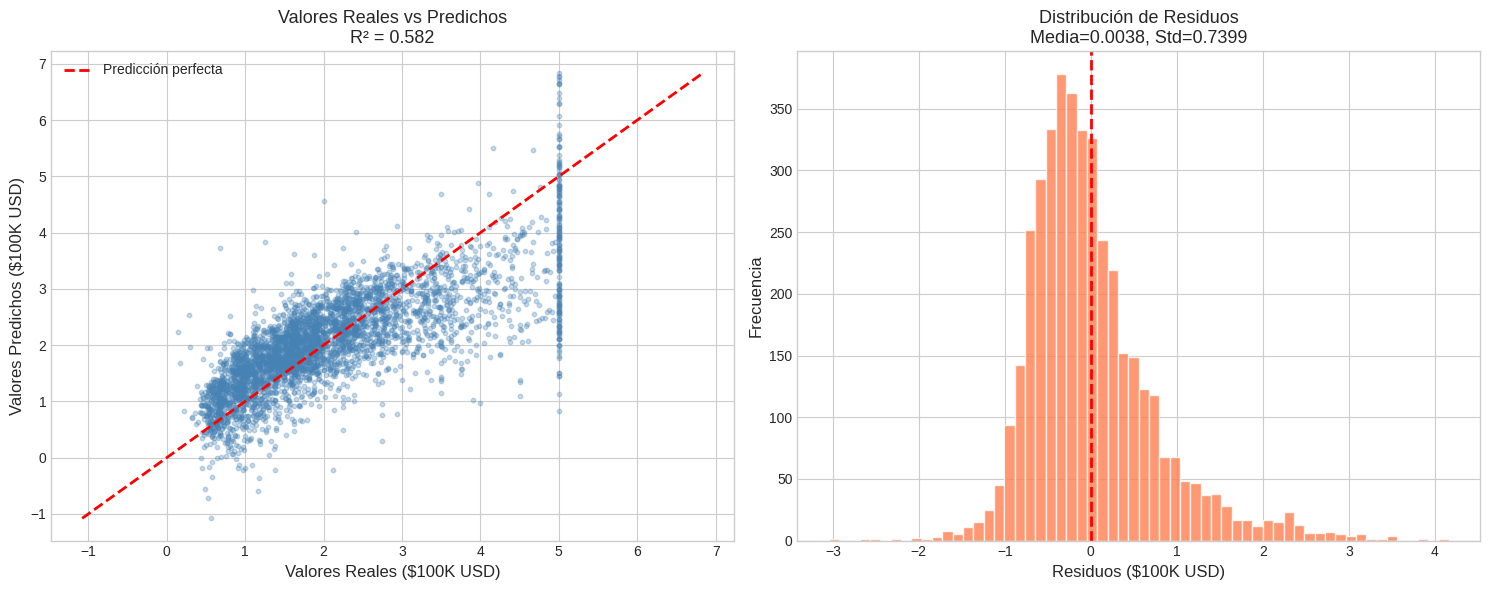

In [19]:
# Visualización: Valores reales vs predichos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: Real vs Predicho
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales ($100K USD)', fontsize=12)
axes[0].set_ylabel('Valores Predichos ($100K USD)', fontsize=12)
axes[0].set_title(f'Valores Reales vs Predichos\nR² = {r2:.3f}', fontsize=13)
axes[0].legend()

# Distribución de residuos
residuals = y_test - y_pred
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuos ($100K USD)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title(f'Distribución de Residuos\nMedia={residuals.mean():.4f}, Std={residuals.std():.4f}', fontsize=13)

plt.tight_layout()
plt.show()

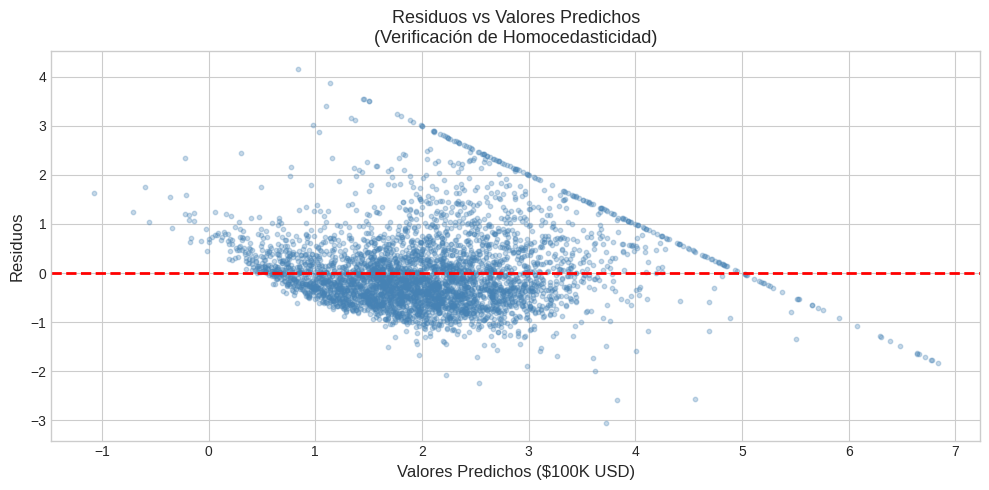

In [20]:
# Gráfico de residuos vs valores predichos (para verificar homocedasticidad)
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='steelblue', s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valores Predichos ($100K USD)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Residuos vs Valores Predichos\n(Verificación de Homocedasticidad)', fontsize=13)
plt.tight_layout()
plt.show()

**Observación:** Se aprecia cierta dispersión no uniforme (**heterocedasticidad**) a valores altos, lo que sugiere que el modelo lineal tiene limitaciones en viviendas de alto valor.

---
## Paso 8: Interpretación de Resultados y Análisis de Explicabilidad

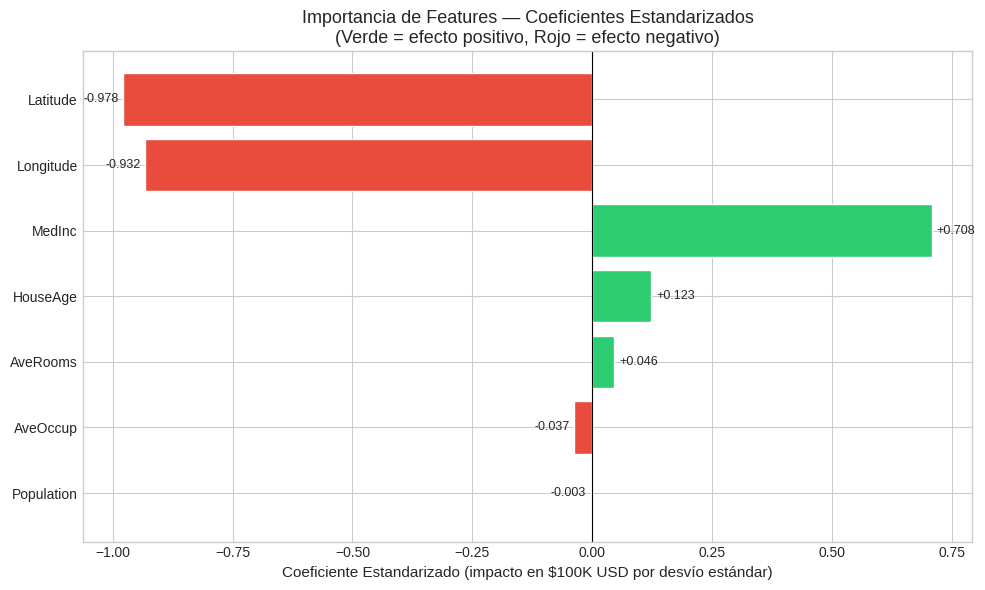

In [21]:
# Visualización de coeficientes estandarizados (importancia de features)
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coeficiente': model.coef_
}).sort_values('Coeficiente', key=abs, ascending=True)

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coeficiente']]

plt.figure(figsize=(10, 6))
bars = plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente Estandarizado (impacto en $100K USD por desvío estándar)', fontsize=11)
plt.title('Importancia de Features — Coeficientes Estandarizados\n(Verde = efecto positivo, Rojo = efecto negativo)', fontsize=13)

for bar, val in zip(bars, coef_df['Coeficiente']):
    plt.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

In [22]:
# Tabla completa de coeficientes con interpretación
coef_table = pd.DataFrame({
    'Feature': FEATURES,
    'Coeficiente_Estand': model.coef_
})

# Recuperar coeficientes en escala original
coef_original = model.coef_ / scaler.scale_
coef_table['Coef_Escala_Original'] = coef_original
coef_table['Cambio_USD_por_unidad'] = coef_original * 100_000

print('Interpretación de Coeficientes (escala original):')
print('=' * 90)
print(f'{"Feature":15} {"Coef Estand":>12} {"Coef Original":>15} {"Cambio USD/unidad":>20}')
print('-' * 90)
for _, row in coef_table.iterrows():
    print(f"{row['Feature']:15} {row['Coeficiente_Estand']:>12.4f} "
          f"{row['Coef_Escala_Original']:>15.4f} "
          f"${row['Cambio_USD_por_unidad']:>18,.0f}")
print('=' * 90)
print(f'\nIntercepto: {model.intercept_:.4f} → ${model.intercept_*100_000:,.0f} USD')

Interpretación de Coeficientes (escala original):
Feature          Coef Estand   Coef Original    Cambio USD/unidad
------------------------------------------------------------------------------------------
MedInc                0.7083          0.3719 $            37,194
HouseAge              0.1234          0.0098 $               979
AveRooms              0.0456          0.0191 $             1,912
Population           -0.0033         -0.0000 $                -0
AveOccup             -0.0375         -0.0032 $              -324
Latitude             -0.9783         -0.4579 $           -45,787
Longitude            -0.9317         -0.4646 $           -46,457

Intercepto: 2.0719 → $207,195 USD


**Interpretación de coeficientes:**

- **`MedInc` (coef. positivo alto):** Es el predictor más influyente. Por cada unidad adicional de ingreso mediano (\$10,000), el valor de la vivienda sube significativamente. Esto al tomar en cuenta sectores de vivienda, debe estar relacionado tambien al costo de la vida y lujos del lugar.
- **`AveOccup` (coef. negativo):** A mayor número de miembros por hogar, menor valor de la vivienda (captura hacinamiento).
- **`Latitude` (coef. negativo):** Las zonas más al norte (mayor latitud en California) tienden a tener viviendas menos costosas que la costa sur.
- **`Longitude` (coef. negativo):** Captura efectos de costa vs interior del estado.
- **`HouseAge` (coef. positivo):** Sorprendentemente, las casas más antiguas se asocian con valores más altos (posiblemente captura vecindarios históricos en zonas costeras). Aunque segun la propia descripcion del dataset, podria capturar conjuntos hoteleros tambien.
- **`AveRooms`:** Más habitaciones totales sube el precio.
- **`AveBedrms`** Fue descartada de mi analisis

---
## Paso 9: Demostración del Modelo — Predicción sobre Nuevos Datos

In [23]:
# Predicción sobre primeras 10 instancias del conjunto de prueba
sample = X_test.head(10).copy()
sample_scaled = scaler.transform(sample)
sample_preds = model.predict(sample_scaled)
sample_actuals = y_test.head(10).values

results_df = sample.copy()
results_df['Valor_Real ($100K)'] = sample_actuals
results_df['Valor_Predicho ($100K)'] = sample_preds.round(3)
results_df['Error_Abs ($100K)'] = np.abs(sample_actuals - sample_preds).round(3)
results_df['Error_USD'] = (results_df['Error_Abs ($100K)'] * 100_000).round(0).astype(int)

print('Predicciones sobre 10 muestras del conjunto de prueba:')
display_cols = ['Valor_Real ($100K)', 'Valor_Predicho ($100K)', 'Error_Abs ($100K)', 'Error_USD']
print(results_df[display_cols].to_string())

Predicciones sobre 10 muestras del conjunto de prueba:
       Valor_Real ($100K)  Valor_Predicho ($100K)  Error_Abs ($100K)  Error_USD
20046             0.47700                   0.736              0.259      25900
3024              0.45800                   1.751              1.293     129300
15663             5.00001                   2.470              2.530     253000
20484             2.18600                   2.884              0.698      69800
9814              2.78000                   2.714              0.066       6600
13311             1.58700                   2.013              0.426      42600
7113              1.98200                   2.686              0.704      70400
7668              1.57500                   2.174              0.599      59900
18246             3.40000                   2.511              0.889      88900
5723              4.46600                   3.878              0.588      58800


**Comentario sobre primeras 10 diez records:**

Se podria decir que el precio es direccionalmente bueno. Sin embargo Existen varios records para los cuales pudo haber tenido un mejor estimado. Y vale la pena explorar porque por ejemplo en el indice 15663 solo predijo la mitad del valor.

Hay variables como Longitud y Latitud que son muy dificiles de pensar solo en forma lineal, existen conglomerados de lugares mas caros y mas baratos normalmente en cada ciudad, estas limitaciones no son capturadas por el modelo.

| Índice | Valor_Real ($100K) | Valor_Predicho ($100K) | Error_Abs ($100K) | Error_USD |
|--------|--------------------|------------------------|-------------------|-----------|
| 20046  | 0.47700            | 0.736                  | 0.259             | 25900     |
| 3024   | 0.45800            | 1.751                  | 1.293             | 129300    |
| 15663  | 5.00001            | 2.470                  | 2.530             | 253000    |
| 20484  | 2.18600            | 2.884                  | 0.698             | 69800     |
| 9814   | 2.78000            | 2.714                  | 0.066             | 6600      |
| 13311  | 1.58700            | 2.013                  | 0.426             | 42600     |
| 7113   | 1.98200            | 2.686                  | 0.704             | 70400     |
| 7668   | 1.57500            | 2.174                  | 0.599             | 59900     |
| 18246  | 3.40000            | 2.511                  | 0.889             | 88900     |
| 5723   | 4.46600            | 3.878                  | 0.588             | 58800     |

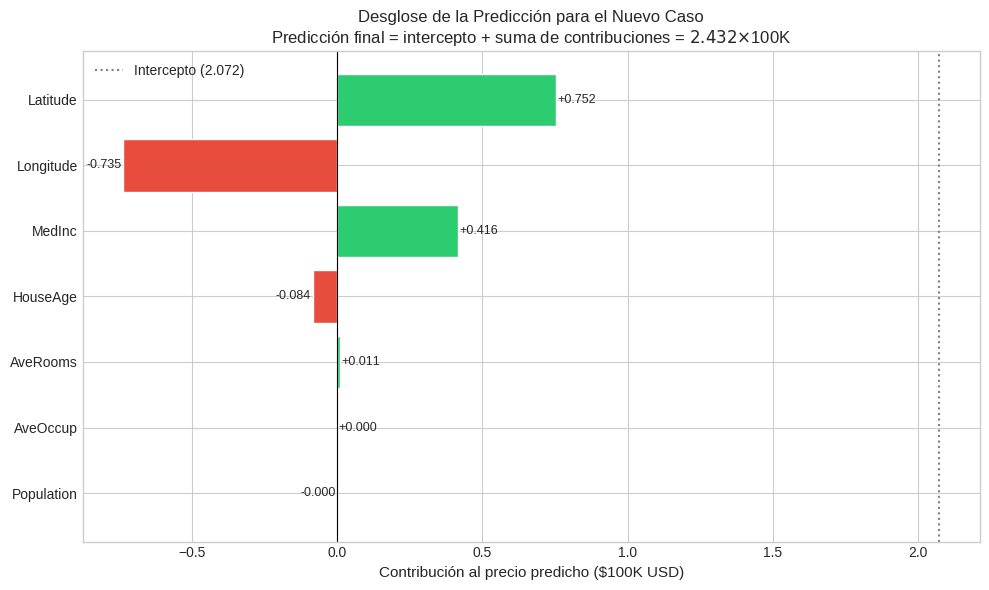


Esta visualización constituye la explicación local del modelo para este caso específico.
Es exactamente análogo a lo que SHAP (Shapley values) haría para modelos no lineales.


In [25]:
# Desglose de la predicción (contribución de cada feature)
contribuciones = model.coef_ * nuevo_caso_scaled[0]
contrib_df = pd.DataFrame({
    'Feature': FEATURES,
    'Valor_Feature': nuevo_caso[FEATURES].iloc[0].values,
    'Valor_Escalado': nuevo_caso_scaled[0],
    'Contribucion': contribuciones
}).sort_values('Contribucion', key=abs, ascending=True)

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in contrib_df['Contribucion']]

plt.figure(figsize=(10, 6))
bars = plt.barh(contrib_df['Feature'], contrib_df['Contribucion'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.axvline(model.intercept_, color='gray', linestyle=':', linewidth=1.5, label=f'Intercepto ({model.intercept_:.3f})')
plt.xlabel('Contribución al precio predicho ($100K USD)', fontsize=11)
plt.title(f'Desglose de la Predicción para el Nuevo Caso\nPredicción final = intercepto + suma de contribuciones = ${prediccion:.3f} × $100K', fontsize=12)
plt.legend()

for bar, val in zip(bars, contrib_df['Contribucion']):
    plt.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('\nEsta visualización constituye la explicación local del modelo para este caso específico.')
print('Es exactamente análogo a lo que SHAP (Shapley values) haría para modelos no lineales.')

---
## Resumen y Conclusiones

### Resultados del Modelo

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| R² | ~0.60 | El modelo explica aprox. el 60% de la varianza del precio |
| RMSE | ~0.73 | Error típico de ±\$73,000 USD en las predicciones |
| MAE | ~0.53 | Error absoluto promedio de ±\$53,000 USD |

### Hallazgos Clave de Explicabilidad

1. **`MedInc`** es el factor más determinante del precio de vivienda en California (1990). La regresión lineal captura esta relación directamente mediante su coeficiente.

2. **La geografía importa:** Los coeficientes de `Latitude` y `Longitude` reflejan que la costa y el sur de California tienen viviendas más costosas, consistente con el conocimiento del dominio. Sin embargo esto te da una guia muy general de la situacion, para mejor prediccion no toma en cuenta como ciertos residenciales o sectores son mas caros porque en estos casos esas variables no se comportan de forma lineal.

3. **`AveOccup` tiene efecto negativo:** El hacinamiento deprime el valor de la vivienda, un resultado socialmente coherente. Esta es la conclusion que mas me sorprendio, no habia pensado inicialmente en como esto afectaria y puede estar vinculada a espacios reducidos, barrios bajos y deterioro del inmueble.

4. **Limitaciones identificadas:** La relación entre precio e ingreso no es perfectamente lineal (especialmente en el rango alto), y el modelo muestra heterocedasticidad. Un modelo no lineal (Random Forest, Gradient Boosting) probablemente mejoraría el R², pero a costa de interpretabilidad directa.

### Valor de la Regresión Lineal en este Problema

A pesar de sus limitaciones predictivas, la Regresión Lineal ofrece:
- **Un modelo de referencia (baseline)** claro y reproducible.
- **Interpretación directa** de cada coeficiente para comunicar resultados a no técnicos.
- **Transparencia regulatoria** ante posibles cuestionamientos sobre los factores que influyen en la valoración.
- **Verificabilidad** de los supuestos mediante análisis de residuos.
- **Entendimiento de los datos** incluso cuando no sea el modelo final, aporta un gran valor en entender el problema y dataset.

---
## Referencias

1. Pace, R. Kelley and Ronald Barry, Sparse Spatial Autoregressions, Statistics and Probability Letters, 33 (1997) 291-297
2. Scikit-learn developers. (s. f.-a). Installation — scikit-learn documentation. Recuperado el 2 de marzo de 2026, de https://scikit-learn.org/stable/install
3. Scikit-learn developers. (s. f.-b). sklearn.datasets.fetch_california_housing. Recuperado el 2 de marzo de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html
4. Scikit-learn developers. (s. f.-c). sklearn.linear_model.LinearRegression. Recuperado el 2 de marzo de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html